In [1]:
# import relevant libraries
!pip install full_fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import requests
from bs4 import BeautifulSoup
import re
from full_fred.fred import Fred
import sklearn as sk
import time
from collections import Counter
import nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.4 MB/s eta 0:00:00


In [2]:
# scrape dates data from FED website calendar
base = 'https://www.federalreserve.gov'
all_dates = []
def get_fomc_meeting_dates():
  # scrape from calendar page
  url = f'{base}/monetarypolicy/fomccalendars.htm'
  soup = BeautifulSoup(requests.get(url).content, 'html.parser')
  links = soup.find_all('a',href=re.compile(r'fomcminutes\d{8}\.htm'))
  for link in links:
    date_str = re.search(r'fomcminutes(\d{8})\.htm',link['href']).group(1)
    all_dates.append(('new',date_str))
  time.sleep(1)

  # scrape from historical pages (pre 2021)
  for year in range(1993,2021):
    url = f'{base}/monetarypolicy/fomchistorical{year}.htm'
    response = requests.get(url)

    if response.status_code != 200:
      print(f'skipping {year}')
      time.sleep(1)
      continue
    soup = BeautifulSoup(response.content, 'html.parser')

    # New format
    new_links = soup.find_all('a', href=re.compile(r'fomcminutes\d{8}\.htm'))
    for link in new_links:
      date_str = re.search(r'fomcminutes(\d{8})\.htm',link['href']).group(1)
      all_dates.append(('new',date_str))
    # old format
    old_links = soup.find_all('a', href=re.compile(r'/fomc/minutes/(\d{8})\.htm'))
    for link in old_links:
        date_str = re.search(r'/fomc/minutes/(\d{8})\.htm', link['href']).group(1)
        all_dates.append(('old', date_str))
    # older format
    oldest_links = soup.find_all('a', href=re.compile(r'/fomc/MINUTES/\d{4}/(\d{8})min\.htm'))
    for link in oldest_links:
        date_str = re.search(r'/fomc/MINUTES/\d{4}/(\d{8})min\.htm', link['href']).group(1)
        all_dates.append(('oldest', date_str))

    found = len(new_links) + len(old_links) + len(oldest_links)
    time.sleep(1)

  all_dates.sort(key=lambda x : x[1])
  return all_dates

fomc_dates = get_fomc_meeting_dates()
print(f'Earliest: {fomc_dates[0]}')
print(f'Latest: {fomc_dates[-1]}')
print(f'Total: {len(fomc_dates)}')


Earliest: ('oldest', '19930203')
Latest: ('new', '20260128')
Total: 277


In [3]:
# scraping for minutes data

def make_url(format_type, date_str):
  if format_type == 'new':
    return f'{base}/monetarypolicy/fomcminutes{date_str}.htm'
  elif format_type == 'old':
      return f'{base}/fomc/minutes/{date_str}.htm'
  elif format_type == 'oldest':
      year = date_str[:4]
      return f'{base}/fomc/MINUTES/{year}/{date_str}min.htm'
  # different time periods of minutes have different html structures

def clean_text(text):
  for cutoff_phrase in ['Notation Vote', 'notation vote','Secretary,\n', '_______']:
    idx = text.find(cutoff_phrase)
    if idx != -1 and idx > len(text) * 0.7:
      text = text[:idx]
      break
  text = ' '.join(text.split())
  return text.strip()


def scrape_minutes(format_type, date_str):
  url = make_url(format_type, date_str)

  try:
      response = requests.get(url, timeout=10)
      if response.status_code != 200:
          return None

      soup = BeautifulSoup(response.content, 'html.parser')

      # Try multiple content containers used across different eras
      content = (soup.find('div', id='article') or
                soup.find('div', id='content') or
                soup.find('body'))


      if not content:
          return None

      text = content.get_text(separator='\n')
      text = clean_text(text)

      if len(text.split()) < 100:
          print(f"Text too short: {date_str}")
          return None

      return text

  except Exception as e:
      print(f"Error on {date_str}: {e}")
      return None

# main scraping loop
records = []
total = len(fomc_dates)

for i, (format_type,date_str) in enumerate(fomc_dates):
  print(f'{i+1}/{total} scraping {date_str} ({format_type})')
  text = scrape_minutes(format_type, date_str)
  if text:
    records.append({
    'date': pd.to_datetime(date_str, format='%Y%m%d'),
    'date_str': date_str,
    'format': format_type,
    'text': text,
    'word_count': len(text.split())
    })
    print(f'{len(text.split())}')
  time.sleep(1)

# build df
df = pd.DataFrame(records)
df = df.sort_values('date').reset_index(drop=True)
# save to csv
df.to_csv('fomc_minutes_raw.csv', index=False)

1/277 scraping 19930203 (oldest)
10589
2/277 scraping 19930323 (oldest)
5817
3/277 scraping 19930518 (oldest)
5037
4/277 scraping 19930707 (oldest)
7234
5/277 scraping 19930817 (oldest)
4733
6/277 scraping 19930921 (oldest)
5032
7/277 scraping 19931116 (oldest)
6177
8/277 scraping 19931221 (oldest)
5892
9/277 scraping 19940204 (oldest)
10553
10/277 scraping 19940322 (oldest)
5916
11/277 scraping 19940322 (oldest)
5916
12/277 scraping 19940517 (oldest)
4973
13/277 scraping 19940706 (oldest)
6817
14/277 scraping 19940816 (oldest)
4977
15/277 scraping 19940927 (oldest)
5163
16/277 scraping 19941115 (oldest)
5702
17/277 scraping 19941220 (oldest)
5783
18/277 scraping 19950201 (oldest)
8359
19/277 scraping 19950328 (oldest)
7866
20/277 scraping 19950523 (oldest)
5051
21/277 scraping 19950706 (oldest)
7078
22/277 scraping 19950822 (oldest)
4443
23/277 scraping 19950926 (oldest)
4975
24/277 scraping 19951115 (oldest)
5143
25/277 scraping 19951219 (oldest)
4946
26/277 scraping 19960130 (old)
9

In [4]:
# df checks
print(f"Total rows: {len(df)}")
print(f"Min word count: {df['word_count'].min()}")
print(f"Any under 100 words: {(df['word_count'] < 100).sum()}")

Total rows: 277
Min word count: 3206
Any under 100 words: 0


In [5]:
# import FRED data
import os
fred = Fred()
os.environ['FRED_API_KEY'] = "940f0987350496a7a64aa7736f8583f8"

fedfunds = fred.get_series_df('FEDFUNDS')

# convert types
fedfunds['date'] = pd.to_datetime(fedfunds['date'])
fedfunds['value'] = pd.to_numeric(fedfunds['value'], errors='coerce')

# keep only relevant info
fedfunds = fedfunds[['date', 'value']].dropna()
fedfunds = fedfunds.sort_values('date')
fedfunds = fedfunds.set_index('date')

# align correctly with meetings
df = pd.read_csv('fomc_minutes_raw.csv')
df['date'] = pd.to_datetime(df['date'])


# find rate at meeting and previous rate
df['rate'] = df['date'].map(lambda d: fedfunds.asof(d)['value'])
df['prev_rate'] = df['rate'].shift(1)
df['rate_change'] = df['rate'] - df['prev_rate']

def label_decision(change):
    if change > 0.05:    return 'hike'
    elif change < -0.05: return 'cut'
    else:                return 'hold'


# create hold, hike, cut column for current meeting
df['decision'] = df['rate_change'].apply(label_decision)
df = df.dropna(subset=['rate_change']).reset_index(drop=True)

df.to_csv('fomc_minutes_labelled.csv', index=False)
print(df['decision'].value_counts())

decision
hold    155
hike     70
cut      51
Name: count, dtype: int64


In [6]:
# trimming minutes removing excess information
def extract_policy_text(text):
  # common phrases found across documents at beginning
  start_phrases = [
      'By unanimous vote, the minutes',  # 1990s format
      'Developments in Financial Markets',  # 2000s+ format
      'Annual Organizational Matters',
      'Staff Review of the Economic',
      'The information reviewed at this meeting',
      'The Manager of the System',
  ]

  start_idx = len(text)  # default to start if nothing found
  for phrase in start_phrases:
      idx = text.find(phrase)
      if idx != -1 and idx < start_idx:
          start_idx = idx
          break

  # common phrases commonly found at end of documents
  end_phrases = [
      'Notation Vote',
      'notation vote',
      'The meeting adjourned',
      'Voting for this action',
      'Voting against this action',
      '_______',
  ]

  end_idx = len(text)
  for phrase in end_phrases:
      idx = text.find(phrase)
      if idx != -1 and idx < end_idx:
          end_idx = idx

  # retrieve middle section
  text = text[start_idx:end_idx]
  text = ' '.join(text.split())
  return text.strip()

In [7]:
# applying tokenisation
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

# segment data into sentences
sentences = []

for _, row in df.iterrows():
    # extract only policy-relevant text first
    clean = extract_policy_text(row['text'])
    meeting_sentences = sent_tokenize(clean)

    for sent in meeting_sentences:
        if len(sent.split()) < 8:
            continue
        sentences.append({
            'date': row['date'],
            'date_str': row['date_str'],
            'decision': row['decision'],
            'rate_change': row['rate_change'],
            'sentence': sent
        })

# create df for sentences
df_sentences = pd.DataFrame(sentences)
df_sentences.to_csv('fomc_sentences.csv', index=False)

# display sentences
print(f"Total sentences: {len(df_sentences)}")
print(f"Avg per meeting: {len(df_sentences)/len(df):.0f}")

# check split
print(df_sentences['decision'].value_counts())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Total sentences: 53436
Avg per meeting: 194
decision
hold    30780
hike    13515
cut      9141
Name: count, dtype: int64


In [8]:
!pip install transformers torch -q

from transformers import BertTokenizer, BertForSequenceClassification
from torch.nn.functional import softmax
import torch
from google.colab import drive
drive.mount('/content/drive')

if os.path.exists('/content/drive/MyDrive/fomc_sentences_classified.csv'):
  df_sentences = pd.read_csv('/content/drive/MyDrive/fomc_sentences_classified.csv')
  df_sentences['date'] = pd.to_datetime(df_sentences['date'])
  print(f"Loaded {len(df_sentences)} classified sentences")
  print(df_sentences['finbert_label'].value_counts())
else:
  print('Running FinBERT inference from scratch')

  # pretrained tokenizer
  tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
  model = BertForSequenceClassification.from_pretrained('ProsusAI/finbert')

  # changing to T4 GPU for quicker runtime
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model = model.to(device)
  model.eval()

  # confirm change
  print(f'Using {device}')

  def classify_sentences(texts,batch_size=32):
    results = []
    for i in range(0,len(texts),batch_size):
      batch = texts[i:i+batch_size]
      inputs = tokenizer(batch,padding=True,truncation=True,
                        max_length=512,return_tensors='pt').to(device)
      with torch.no_grad():
        outputs = model(**inputs)
        probs = softmax(outputs.logits, dim=1)
        predictions = probs.argmax(dim=1).cpu().numpy()
        scores = probs.cpu().numpy()

        for pred, score in zip(predictions, scores):
          results.append({
              'label':         ['positive', 'negative', 'neutral'][pred],
              'hawkish_score': float(score[0]),
              'dovish_score':  float(score[1]),
              'neutral_score': float(score[2])
          })

      if i % 4000 == 0:
          print(f"Processed {i}/{len(texts)} sentences...")

    return results

  # apply to all sentences
  texts = df_sentences['sentence'].tolist()
  classifications = classify_sentences(texts)

  # add results to dataframe
  df_sentences['finbert_label'] = [r['label'] for r in classifications]
  df_sentences['hawkish_score'] = [r['hawkish_score'] for r in classifications]
  df_sentences['dovish_score']  = [r['dovish_score'] for r in classifications]
  df_sentences['neutral_score'] = [r['neutral_score'] for r in classifications]

  df_sentences.to_csv('/content/drive/MyDrive/fomc_sentences_classified.csv', index=False)
  print("Saved to Drive!")
  print(df_sentences['finbert_label'].value_counts())

Mounted at /content/drive
Loaded 54976 classified sentences
finbert_label
negative    21879
positive    21441
neutral     11656
Name: count, dtype: int64


In [9]:
# exploratory analysis
# aggregate sentence level to meeting level
meeting_scores = df_sentences.groupby('date').agg(
    total_sentences = ('finbert_label', 'count'),
    hawkish_count   = ('finbert_label', lambda x: (x == 'negative').sum()),
    dovish_count    = ('finbert_label', lambda x: (x == 'positive').sum()),
    neutral_count   = ('finbert_label', lambda x: (x == 'neutral').sum()),
    decision        = ('decision', 'first')
).reset_index()

# compute proportions
# Compute scores as proportions of total sentences
meeting_scores['hawkish_score'] = (meeting_scores['hawkish_count'] / meeting_scores['total_sentences'])
meeting_scores['dovish_score'] = (meeting_scores['dovish_count'] / meeting_scores['total_sentences'])

# rename dovish score to policy score
meeting_scores['policy_score'] = meeting_scores['dovish_score']

# findings
print("Mean policy score by decision type:")
print(meeting_scores.groupby('decision')['policy_score'].mean().round(3))


Mean policy score by decision type:
decision
cut     0.363
hike    0.429
hold    0.394
Name: policy_score, dtype: float64


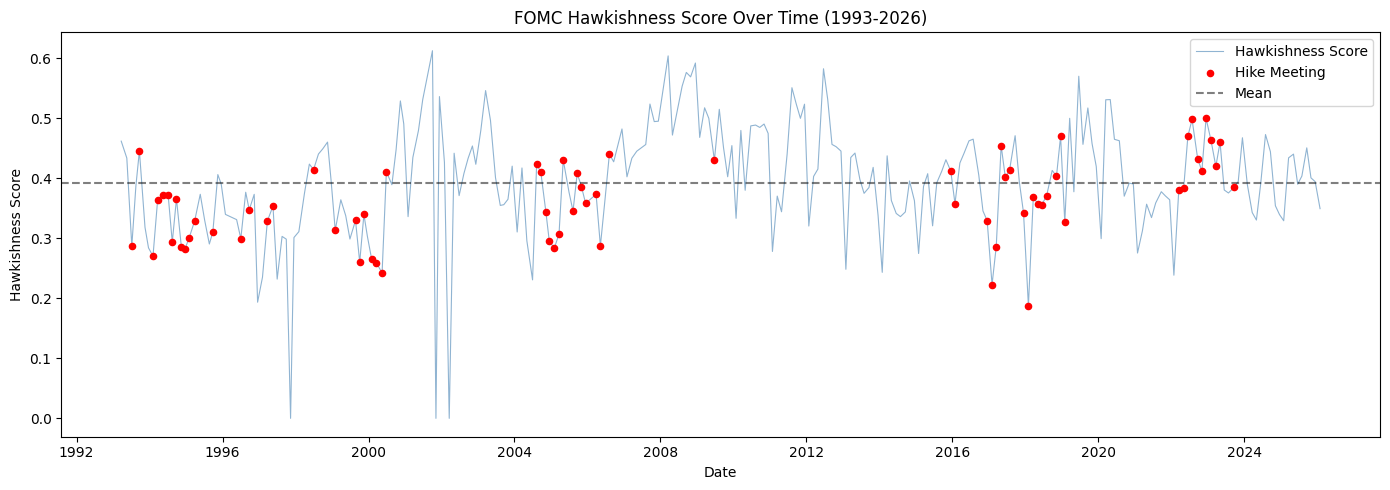

In [10]:
# hawkishness plot
plt.figure(figsize=(14, 5))
plt.plot(meeting_scores['date'], meeting_scores['hawkish_score'],
         alpha=0.6, linewidth=0.8, color='steelblue', label='Hawkishness Score')

# Highlight hike meetings in red
hikes = meeting_scores[meeting_scores['decision'] == 'hike']
plt.scatter(hikes['date'], hikes['hawkish_score'],
            color='red', s=20, zorder=5, label='Hike Meeting')

plt.axhline(meeting_scores['hawkish_score'].mean(),
            color='black', linestyle='--', alpha=0.5, label='Mean')
plt.title('FOMC Hawkishness Score Over Time (1993-2026)')
plt.xlabel('Date')
plt.ylabel('Hawkishness Score')
plt.legend()
plt.tight_layout()

In [11]:
# T+1 labels and date normalisation

# create label
meeting_scores = meeting_scores.sort_values('date').reset_index(drop=True)
meeting_scores['next_decision'] = meeting_scores['decision'].shift(-1)
meeting_scores = meeting_scores.dropna(subset=['next_decision'])

print("T+1 decision distribution:")
print(meeting_scores['next_decision'].value_counts())
print(f"\nTotal meetings for prediction: {len(meeting_scores)}")

# ensure dates match exactly
meeting_scores['date'] = pd.to_datetime(meeting_scores['date']).dt.normalize()
df_sentences['date']   = pd.to_datetime(df_sentences['date']).dt.normalize()

# each sentence inherits the next decision label
next_decision_map = dict(zip(
    meeting_scores['date'],
    meeting_scores['next_decision']
))

df_sentences['next_decision'] = df_sentences['date'].map(next_decision_map)
df_sentences = df_sentences.dropna(subset=['next_decision'])

T+1 decision distribution:
next_decision
hold    139
hike     69
cut      50
Name: count, dtype: int64

Total meetings for prediction: 258


In [12]:
# train/val/test split

train_sents = df_sentences[df_sentences['date'] < '2018-01-01']
val_sents   = df_sentences[(df_sentences['date'] >= '2018-01-01') &
                           (df_sentences['date'] <  '2022-01-01')]
test_sents  = df_sentences[df_sentences['date'] >= '2022-01-01']

print(f"\nTrain next_decision distribution:")
print(train_sents['next_decision'].value_counts())
print(f"\nVal next_decision distribution:")
print(val_sents['next_decision'].value_counts())
print(f"\nTest next_decision distribution:")
print(test_sents['next_decision'].value_counts())


Train next_decision distribution:
next_decision
hold    21977
hike     9234
cut      7246
Name: count, dtype: int64

Val next_decision distribution:
next_decision
hold    5575
hike    1706
cut     1458
Name: count, dtype: int64

Test next_decision distribution:
next_decision
hold    2947
hike    2907
cut     1740
Name: count, dtype: int64


In [13]:
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
import torch

label2id = {'hold': 0, 'hike': 1, 'cut': 2}
id2label  = {0: 'hold', 1: 'hike', 2: 'cut'}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class FOMCDataset(Dataset):
  def __init__(self, sentences, labels, tokenizer, max_length=128):
    self.sentences  = sentences
    self.labels     = [label2id[l] for l in labels]
    self.tokenizer  = tokenizer
    self.max_length = max_length

  def __len__(self):
    return len(self.sentences)

  def __getitem__(self, idx):
    # Tokenise sentence using FinBERT WordPiece tokeniser
    # padding='max_length' ensures all sentences same length for batching
    # truncation=True handles rare sentences over 128 tokens
    encoded = self.tokenizer(
        self.sentences[idx],
        padding='max_length',
        truncation=True,
        max_length=self.max_length,
        return_tensors='pt'
    )
    return {
        'input_ids':      encoded['input_ids'].squeeze(),
        'attention_mask': encoded['attention_mask'].squeeze(),
        'label':          torch.tensor(self.labels[idx], dtype=torch.long)
    }

# load FinBERT tokenizer
tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')

# build datasets for each split
train_dataset = FOMCDataset(
    train_sents['sentence'].tolist(),
    train_sents['next_decision'].tolist(),
    tokenizer)
val_dataset = FOMCDataset(
    val_sents['sentence'].tolist(),
    val_sents['next_decision'].tolist(),
    tokenizer)
test_dataset = FOMCDataset(
    test_sents['sentence'].tolist(),
    test_sents['next_decision'].tolist(),
    tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [14]:
# hyperparameter grid search
import itertools
import os
from transformers import BertForSequenceClassification, BertTokenizer
from torch.optim import AdamW
from torch.nn.functional import cross_entropy
from torch.nn.utils import clip_grad_norm_
from sklearn.metrics import f1_score

if os.path.exists('/content/drive/MyDrive/hp_search_results.csv'):
    print("Loading hyperparameter search results from Drive...")
    results_df = pd.read_csv('/content/drive/MyDrive/hp_search_results.csv')
    print(results_df.to_string(index=False))
    print("\nBest configuration: LR=1e-5, batch_size=16, epoch=2")

    model = BertForSequenceClassification.from_pretrained(
        '/content/drive/MyDrive/finbert_hp_lr1e-05_bs16')
    tokenizer = BertTokenizer.from_pretrained(
        '/content/drive/MyDrive/finbert_hp_lr1e-05_bs16')
    model = model.to(device)
    model.eval()
    print("Best model loaded!")

else:
    print("Running hyperparameter search from scratch...")

    learning_rates = [1e-5, 2e-5, 3e-5]
    batch_sizes = [16, 32]
    EPOCHS = 3

    class_counts = train_sents['next_decision'].value_counts()
    total = len(train_sents)
    weights = torch.tensor([
        total / class_counts['hold'],
        total / class_counts['hike'],
        total / class_counts['cut']
    ], dtype=torch.float).to(device)

    results = []

    for lr, bs in itertools.product(learning_rates, batch_sizes):
        print(f"LR: {lr} | Batch size: {bs} | Epochs: {EPOCHS}")

        train_loader_hp = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        val_loader_hp = DataLoader(val_dataset,   batch_size=bs, shuffle=False)

        model_hp = BertForSequenceClassification.from_pretrained(
            'ProsusAI/finbert',
            num_labels=3,
            ignore_mismatched_sizes=True).to(device)

        optimizer_hp = AdamW(model_hp.parameters(), lr=lr)

        best_f1 = 0
        best_epoch = 0

        for epoch in range(EPOCHS):
            model_hp.train()
            total_loss = 0

            for i, batch in enumerate(train_loader_hp):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)

                optimizer_hp.zero_grad()
                outputs = model_hp(input_ids=input_ids,
                                   attention_mask=attention_mask)
                loss = cross_entropy(outputs.logits, labels, weight=weights)
                loss.backward()
                clip_grad_norm_(model_hp.parameters(), max_norm=1.0)
                optimizer_hp.step()
                total_loss += loss.item()

                print_every = 400 if bs == 16 else 200
                if i % print_every == 0:
                    print(f"  Epoch {epoch+1} | Batch {i}/{len(train_loader_hp)} | Loss: {loss.item():.4f}")

            avg_loss = total_loss / len(train_loader_hp)

            model_hp.eval()
            val_preds, val_labels_list = [], []

            with torch.no_grad():
                for batch in val_loader_hp:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    outputs = model_hp(input_ids=input_ids,
                                       attention_mask=attention_mask)
                    preds = outputs.logits.argmax(dim=1).cpu().numpy()
                    val_preds.extend(preds)
                    val_labels_list.extend(batch['label'].numpy())

            val_preds_named = [id2label[p] for p in val_preds]
            val_labels_named = [id2label[l] for l in val_labels_list]

            macro_f1 = f1_score(val_labels_named, val_preds_named,
                                average='macro', zero_division=0)

            print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f} | Val Macro F1: {macro_f1:.3f}")

            if macro_f1 > best_f1:
                best_f1 = macro_f1
                best_epoch = epoch + 1
                save_path = f'/content/drive/MyDrive/finbert_hp_lr{lr}_bs{bs}'
                model_hp.save_pretrained(save_path)
                tokenizer.save_pretrained(save_path)
                print(f"Saved: {save_path}")

        results.append({
            'learning_rate': lr,
            'batch_size': bs,
            'best_epoch': best_epoch,
            'best_val_f1': round(best_f1, 4)})
        print(f"\nBest for LR={lr}, BS={bs}: F1={best_f1:.3f} at epoch {best_epoch}")

    results_df = pd.DataFrame(results).sort_values('best_val_f1', ascending=False)
    print(results_df.to_string(index=False))
    results_df.to_csv('/content/drive/MyDrive/hp_search_results.csv', index=False)
    print("Results saved to Drive!")

Loading hyperparameter search results from Drive...
 learning_rate  batch_size  best_epoch  best_val_f1
       0.00001          16           2       0.4185
       0.00001          32           3       0.4164
       0.00003          16           2       0.4156
       0.00002          32           3       0.4091
       0.00002          16           2       0.4031
       0.00003          32           1       0.3955

Best configuration: LR=1e-5, batch_size=16, epoch=2


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Best model loaded!


In [15]:
# test evaluation
from transformers import BertForSequenceClassification, BertTokenizer
from sklearn.metrics import classification_report
from collections import Counter

# sentence level predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend([id2label[p] for p in preds])
        all_labels.extend([id2label[l] for l in batch['label'].numpy()])
print(Counter(all_preds))

# aggregate to meeting level
test_sents_copy = test_sents.copy()
test_sents_copy['pred'] = all_preds
test_sents_copy['true'] = all_labels

meeting_results = test_sents_copy.groupby('date').agg(
    true_label = ('true', lambda x: x.mode()[0]),
    pred_label = ('pred', lambda x: x.mode()[0])).reset_index()

# meeting level results
print(classification_report(
    meeting_results['true_label'],
    meeting_results['pred_label'],
    labels=['hold', 'hike', 'cut'],
    target_names=['hold', 'hike', 'cut'],
    zero_division=0))


Counter({'hold': 4715, 'hike': 2210, 'cut': 669})
              precision    recall  f1-score   support

        hold       0.41      1.00      0.58        13
        hike       0.00      0.00      0.00        11
         cut       0.00      0.00      0.00         8

    accuracy                           0.41        32
   macro avg       0.14      0.33      0.19        32
weighted avg       0.17      0.41      0.23        32



In [16]:
# baseline TD-IDF with logreg
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# reconstruct meeting level text
df_labelled = df_sentences.groupby(['date', 'decision']).agg(
    text = ('sentence', ' '.join)).reset_index().sort_values('date').reset_index(drop=True)

# T+1 labels
df_labelled['next_decision'] = df_labelled['decision'].shift(-1)
df_labelled = df_labelled.dropna(subset=['next_decision'])

# equal split for fair comparison
train_bl = df_labelled[df_labelled['date'] < '2018-01-01']
test_bl  = df_labelled[df_labelled['date'] >= '2022-01-01']

# TF-IDF vectorisation
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(train_bl['text'])
X_test  = vectorizer.transform(test_bl['text'])

# log reg
clf = LogisticRegression(max_iter=1000, class_weight='balanced') # include balanced class weight
clf.fit(X_train, train_bl['next_decision'])
y_pred = clf.predict(X_test)

# baseline results
print(classification_report(
    test_bl['next_decision'],
    y_pred,
    labels=['hold', 'hike', 'cut'],
    target_names=['hold', 'hike', 'cut'],
    zero_division=0))

              precision    recall  f1-score   support

        hold       0.43      1.00      0.60        13
        hike       1.00      0.09      0.17        11
         cut       0.00      0.00      0.00         7

    accuracy                           0.45        31
   macro avg       0.48      0.36      0.26        31
weighted avg       0.54      0.45      0.31        31



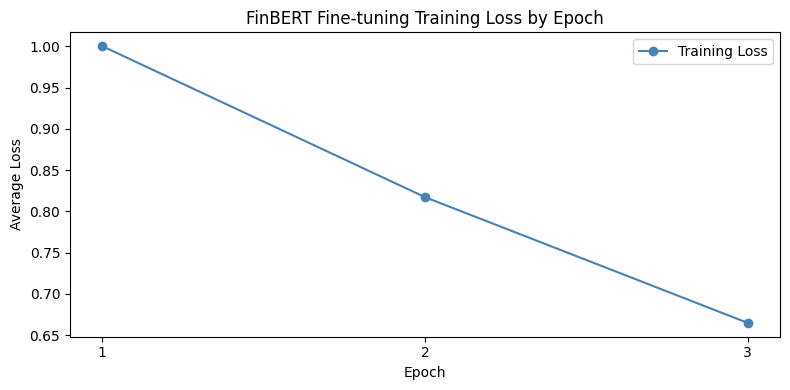

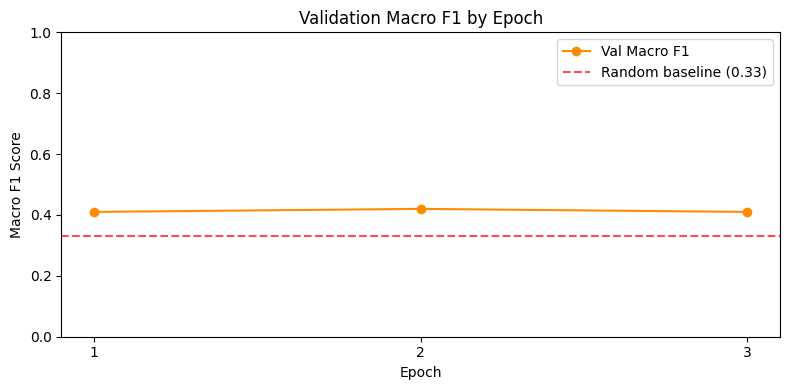

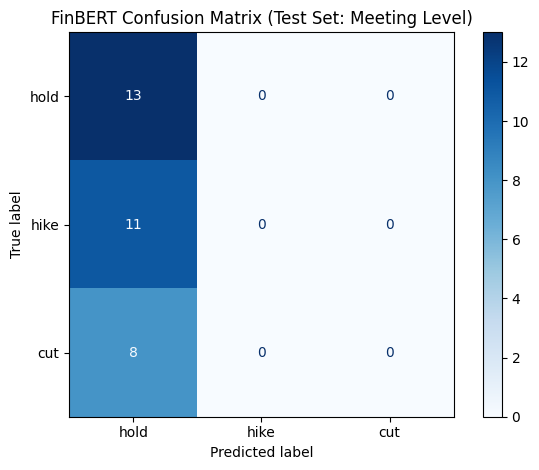

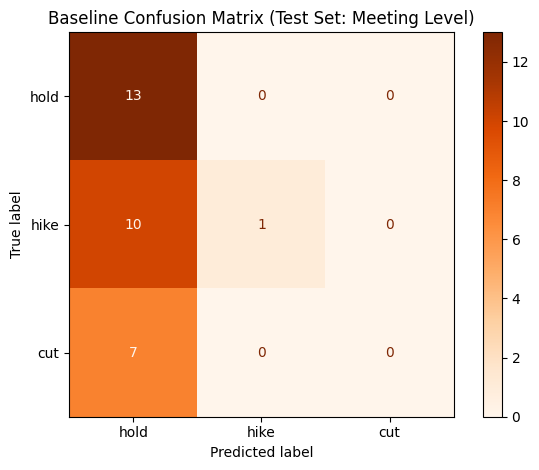

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# values from ealier runs
epochs = [1, 2, 3]
train_loss = [1.0001, 0.8172, 0.6649]
macro_f1 = [0.41, 0.42, 0.41]

# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss, marker='o', color='steelblue', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('FinBERT Fine-tuning Training Loss by Epoch')
plt.xticks(epochs)
plt.legend()
plt.tight_layout()
plt.show()

# validation macro F1 Curve
plt.figure(figsize=(8, 4))
plt.plot(epochs, macro_f1, marker='o', color='darkorange', label='Val Macro F1')
plt.axhline(0.33, color='red', linestyle='--', alpha=0.7, label='Random baseline (0.33)')
plt.xlabel('Epoch')
plt.ylabel('Macro F1 Score')
plt.title('Validation Macro F1 by Epoch')
plt.xticks(epochs)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# FinBERT confusion matrix
cm = confusion_matrix(
    meeting_results['true_label'],
    meeting_results['pred_label'],
    labels=['hold', 'hike', 'cut'])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['hold', 'hike', 'cut'])
disp.plot(cmap='Blues')
plt.title('FinBERT Confusion Matrix (Test Set: Meeting Level)')
plt.tight_layout()
plt.show()

# baseline confusion matrix
cm_bl = confusion_matrix(
    test_bl['next_decision'],
    y_pred,
    labels=['hold', 'hike', 'cut']
)
disp_bl = ConfusionMatrixDisplay(
    confusion_matrix=cm_bl,
    display_labels=['hold', 'hike', 'cut']
)
disp_bl.plot(cmap='Oranges')
plt.title('Baseline Confusion Matrix (Test Set: Meeting Level)')
plt.tight_layout()
plt.show()